# 05 - Model Comparison

Compares all trained classifiers, i.e. scikit-learn (LR, RF, GBM, Ensemble) and PyTorch MLP (mlp_impute, mlp_mask), across the three split types:
- `within_sim`,
- `cross_softening`, 
- and `cross_z_ini`

**Structure per split:**
1. Metrics summary (from MLflow)
2. Precision-recall curves
3. ROC curves
4. Confusion matrices


## Setup

In [22]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="mlflow")

import os
from pathlib import Path

project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(project_root)

_latex = os.environ.get("LATEX_BIN_DIR")
if _latex:
    os.environ["PATH"] = _latex + ":" + os.environ["PATH"]

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import polars as pl
import torch

from src.config import load_config
from src.db import get_connection
from src.gold.features import FEATURE_COLS
from src.models.evaluate import (
    compute_metrics,
    load_model,
    load_mlp_model,
    plot_confusion_matrix,
    plot_pr_curve,
    plot_roc_curve,
)
from src.models.mlp import NULLABLE_FEATURES
from src.utils.plotting import apply_style

apply_style()

cfg = load_config()
mlflow.set_tracking_uri(cfg.mlflow.tracking_uri)

MODELS_DIR  = Path("models")
SPLITS      = ["within_sim", "cross_softening", "cross_z_ini"]
SKL_MODELS  = ["lr", "rf", "gbm", "ensemble"]
MLP_NAMES   = ["mlp_impute", "mlp_mask"]

## Helper functions

In [ ]:
def load_test_data(split_name: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load X_test and y_test for a given split from the gold tables
    """
    conn = get_connection(cfg.database_path, read_only=True)
    feature_cols_sql = ", ".join(f"f.{c}" for c in FEATURE_COLS)
    df = conn.execute(f"""
        SELECT
            {feature_cols_sql},
            l.is_spurious_cdm_match AS label
        FROM gold.features f
        JOIN gold.labels l
            ON f.halo_id = l.halo_id AND f.simulation_id = l.simulation_id
        JOIN gold.train_test_splits s
            ON f.halo_id = s.halo_id AND f.simulation_id = s.simulation_id
        WHERE s.split_name = '{split_name}'
          AND s.split_role  = 'test'
          AND l.is_spurious_cdm_match IS NOT NULL
    """).pl()
    conn.close()
    X_test = df.select(FEATURE_COLS).to_numpy()
    y_test = df["label"].cast(pl.Int8).to_numpy()
    return X_test, y_test


def compute_train_means(split_name: str) -> np.ndarray:
    """
    Compute training-set column means for MLP imputation (NaN-aware)
    """
    conn = get_connection(cfg.database_path, read_only=True)
    feature_cols_sql = ", ".join(f"f.{c}" for c in FEATURE_COLS)
    df = conn.execute(f"""
        SELECT {feature_cols_sql}
        FROM gold.features f
        JOIN gold.train_test_splits s
            ON f.halo_id = s.halo_id AND f.simulation_id = s.simulation_id
        WHERE s.split_name = '{split_name}'
          AND s.split_role = 'train'
    """).pl()
    conn.close()
    return np.nanmean(df.select(FEATURE_COLS).to_numpy().astype(np.float32), axis=0)


def _preprocess_for_mlp(
    X: np.ndarray,
    use_mask: bool,
    col_means: np.ndarray,
) -> np.ndarray:
    """
    Apply imputation or masking preprocessing matching train_pytorch.py
    """
    nullable_idx = [FEATURE_COLS.index(f) for f in NULLABLE_FEATURES]
    if use_mask:
        indicators = np.isnan(X[:, nullable_idx]).astype(np.float32)
        X_filled = np.where(np.isnan(X), 0.0, X).astype(np.float32)
        return np.hstack([X_filled, indicators])
    X_filled = X.copy().astype(np.float32)
    for j, mean in enumerate(col_means):
        mask_j = np.isnan(X_filled[:, j])
        X_filled[mask_j, j] = mean
    return X_filled


def get_mlp_proba(
    model: object,
    X_raw: np.ndarray,
    use_mask: bool,
    col_means: np.ndarray,
) -> np.ndarray:
    """
    Return predicted spurious-class probabilities from an MLP
    """
    X_proc = _preprocess_for_mlp(X_raw, use_mask, col_means)
    with torch.no_grad():
        logits = model(torch.from_numpy(X_proc))
        return torch.sigmoid(logits).numpy().ravel()


def get_mlflow_metrics(split_name: str) -> pl.DataFrame:
    """
    Pull MLflow run metrics for a given split, sorted by avg precision
    """
    runs = mlflow.search_runs(
        experiment_names=["spurious_halo_classifier"],
        filter_string=f"params.split_name = '{split_name}'",
    )
    if runs.empty:
        print(f"No MLflow runs found for split '{split_name}'.")
        return pl.DataFrame()

    keep_cols = [
        "params.model",
        "metrics.test_average_precision",
        "metrics.test_roc_auc",
        "metrics.test_f1",
        "metrics.test_f1_genuine",
        "metrics.test_precision",
        "metrics.test_recall",
        "metrics.test_precision_genuine",
        "metrics.test_recall_genuine",
    ]
    available = [c for c in keep_cols if c in runs.columns]
    return (
        pl.from_pandas(runs[available])
        .rename({c: c.split(".")[-1] for c in available})
        .sort("test_average_precision", descending=True)
    )


## Metrics reference

Before interpreting the results, a brief explanation of the metrics used throughout this notebook.

### The confusion matrix

All metrics derive from four counts at a fixed decision threshold (default 0.5):

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actually Positive** | True Positive (TP) | False Negative (FN) |
| **Actually Negative** | False Positive (FP) | True Negative (TN) |

In this project: **Positive = Spurious**, **Negative = Genuine**.

### Threshold-dependent metrics

**Precision** — of everything predicted spurious, how many actually are?
$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall** — of all genuinely spurious haloes, how many did we catch?
$$\text{Recall} = \frac{TP}{TP + FN}$$

**F1** — harmonic mean of precision and recall:
$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

#### Important:
We report these for **both classes**, spurious (positive) and genuine (negative), flipping what is the positive class. 

With ~81\% spurious, a lazy classifier can score well on spurious metrics while ignoring genuine haloes entirely. Genuine-class metrics are the harder and more scientifically meaningful diagnostic.

### Threshold-independent metrics

**ROC-AUC**, area under the receiver operating characteristic curve (true positive rate vs false positive rate). This is the probability that the model ranks a random spurious halo above a random genuine one. It is an optimistic metric when dealing with class imbalance.

**Average Precision (AP / PR-AUC)**, area under the precision-recall curve. The baseline is of this metric is the class prevalence (~0.81). The metric is more sensitive to class imbalance than ROC-AUC and our **primary metric** for GridSearchCV and model comparison.

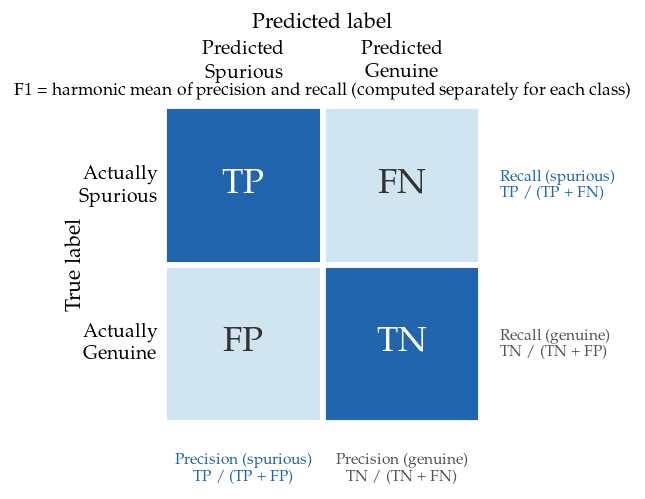

In [45]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_aspect("equal")
ax.axis("off")

# Cell fills
cell_colors = {
    (0, 0): "#2166ac", (0, 1): "#d1e5f0",
    (1, 0): "#d1e5f0", (1, 1): "#2166ac",
}
cell_labels = {
    (0, 0): "TP", (0, 1): "FN",
    (1, 0): "FP", (1, 1): "TN",
}
for (row, col), color in cell_colors.items():
    rect = plt.Rectangle([col, 1 - row], 1, 1, color=color, ec="white", lw=3)
    _ = ax.add_patch(rect)
    text_color = "white" if color == "#2166ac" else "#333333"
    _ = ax.text(
        col + 0.5, 1 - row + 0.5, cell_labels[(row, col)],
        ha="center", va="center", fontsize=18, fontweight="bold",
        color=text_color,
    )

# Column headers
_ = ax.text(0.5, 2.15, "Predicted\nSpurious", ha="center", va="bottom", fontsize=10)
_ = ax.text(1.5, 2.15, "Predicted\nGenuine",  ha="center", va="bottom", fontsize=10)
_ = ax.text(1.0, 2.45, "Predicted label", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Row headers
_ = ax.text(-0.05, 1.5, "Actually\nSpurious", ha="right", va="center", fontsize=10)
_ = ax.text(-0.05, 0.5, "Actually\nGenuine",  ha="right", va="center", fontsize=10)
_ = ax.text(-0.55, 1.0, "True label", ha="center", va="center", fontsize=11,
            fontweight="bold", rotation=90)

# Column brackets: precision
_ = ax.annotate("", xy=(0.5, -0.08), xytext=(0.0, -0.08),
                arrowprops=dict(arrowstyle="-", color="#2166ac", lw=2))
_ = ax.annotate("", xy=(0.5, -0.08), xytext=(1.0, -0.08),
                arrowprops=dict(arrowstyle="-", color="#2166ac", lw=2))
_ = ax.text(0.5, -0.18, "Precision (spurious)\nTP / (TP + FP)",
            ha="center", va="top", fontsize=8, color="#2166ac")

_ = ax.annotate("", xy=(1.5, -0.08), xytext=(1.0, -0.08),
                arrowprops=dict(arrowstyle="-", color="#555555", lw=2))
_ = ax.annotate("", xy=(1.5, -0.08), xytext=(2.0, -0.08),
                arrowprops=dict(arrowstyle="-", color="#555555", lw=2))
_ = ax.text(1.5, -0.18, "Precision (genuine)\nTN / (TN + FN)",
            ha="center", va="top", fontsize=8, color="#555555")

# Row brackets: recall
_ = ax.annotate("", xy=(2.08, 1.5), xytext=(2.08, 2.0),
                arrowprops=dict(arrowstyle="-", color="#2166ac", lw=2))
_ = ax.annotate("", xy=(2.08, 1.5), xytext=(2.08, 1.0),
                arrowprops=dict(arrowstyle="-", color="#2166ac", lw=2))
_ = ax.text(2.12, 1.5, "Recall (spurious)\nTP / (TP + FN)",
            ha="left", va="center", fontsize=8, color="#2166ac")

_ = ax.annotate("", xy=(2.08, 0.5), xytext=(2.08, 1.0),
                arrowprops=dict(arrowstyle="-", color="#555555", lw=2))
_ = ax.annotate("", xy=(2.08, 0.5), xytext=(2.08, 0.0),
                arrowprops=dict(arrowstyle="-", color="#555555", lw=2))
_ = ax.text(2.12, 0.5, "Recall (genuine)\nTN / (TN + FP)",
            ha="left", va="center", fontsize=8, color="#555555")

_ = ax.set_title(
    "F1 = harmonic mean of precision and recall (computed separately for each class)",
    fontsize=9,
)

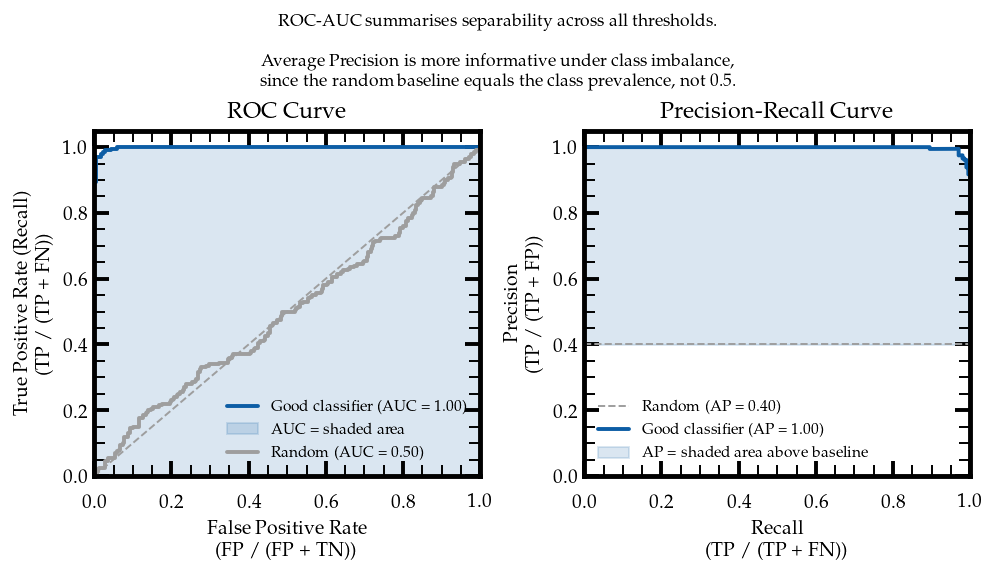

In [51]:
rng = np.random.default_rng(1122334455)

# Generate synthetic scores: a good classifier and a random one.
n = 500
y_true = np.array([1] * 200 + [0] * 300)
scores_good   = np.where(y_true == 1,
                    rng.beta(8, 2, n), rng.beta(2, 8, n))
scores_random = rng.uniform(0, 1, n)

from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(7, 4), constrained_layout=True)

# --- ROC curve ---
ax = axes[0]
for scores, label, color in [
    (scores_good,   "Good classifier", "0C5DA5"),
    (scores_random, "Random",          "9e9e9e"),
]:
    fpr, tpr, _ = roc_curve(y_true, scores)
    area = auc(fpr, tpr)
    _ = ax.plot(fpr, tpr, color=f"#{color}", label=f"{label} (AUC = {area:.2f})")
    if label == "Good classifier":
        _ = ax.fill_between(fpr, tpr, alpha=0.15, color=f"#{color}",
                            label="AUC = shaded area")

_ = ax.plot([0, 1], [0, 1], "--", color="#9e9e9e", linewidth=1)
_ = ax.set_xlabel("False Positive Rate\n(FP / (FP + TN))")
_ = ax.set_ylabel("True Positive Rate (Recall)\n(TP / (TP + FN))")
_ = ax.set_title("ROC Curve")
_ = ax.legend(fontsize=8)
_ = ax.set_xlim(0, 1)
_ = ax.set_ylim(0, 1.05)

# --- PR curve ---
ax = axes[1]
prevalence = y_true.mean()
_ = ax.axhline(prevalence, linestyle="--", color="#9e9e9e", linewidth=1,
               label=f"Random (AP = {prevalence:.2f})")

for scores, label, color in [
    (scores_good, "Good classifier", "0C5DA5"),
]:
    prec, rec, _ = precision_recall_curve(y_true, scores)
    area = auc(rec, prec)
    _ = ax.plot(rec, prec, color=f"#{color}", label=f"{label} (AP = {area:.2f})")
    _ = ax.fill_between(rec, prec, prevalence, alpha=0.15, color=f"#{color}",
                        label="AP = shaded area above baseline")

_ = ax.set_xlabel("Recall\n(TP / (TP + FN))")
_ = ax.set_ylabel("Precision\n(TP / (TP + FP))")
_ = ax.set_title("Precision-Recall Curve")
_ = ax.legend(fontsize=8)
_ = ax.set_xlim(0, 1)
_ = ax.set_ylim(0, 1.05)

_ = fig.suptitle(
    "ROC-AUC summarises separability across all thresholds.\n\n"
    "Average Precision is more informative under class imbalance,\n"
    "since the random baseline equals the class prevalence, not 0.5.",
    fontsize=9,
)

## Within-simulation (standard benchmark)

Train and test on the same simulation (`wdm_512_z39_fixed`). 

In-distribution benchmark, we expect this to be an upper bound on performance.

In [26]:
get_mlflow_metrics("within_sim")

model,test_average_precision,test_roc_auc,test_f1,test_f1_genuine,test_precision,test_recall,test_precision_genuine,test_recall_genuine
str,f64,f64,f64,f64,f64,f64,f64,f64
"""mlp_mask""",0.986471,0.953386,0.946435,0.780521,0.97248,0.921748,0.703337,0.876733
"""mlp_impute""",0.986194,0.952973,0.943866,0.774629,0.973985,0.915553,0.689076,0.884438
"""gbm""",0.985865,0.953165,0.949293,0.784757,0.968453,0.930877,0.723958,0.856703
"""rf""",0.985208,0.949402,0.96494,0.820428,0.952079,0.978155,0.881416,0.767334
"""ensemble""",0.985178,0.952117,0.955431,0.803493,0.967569,0.943593,0.761379,0.850539
"""lr""",0.981648,0.943823,0.926813,0.729798,0.97447,0.8836,0.618182,0.890601


### Load test data and models

In [ ]:
X_test_within_sim, y_test_within_sim = load_test_data("within_sim")
col_means_within_sim = compute_train_means("within_sim")

# Sklearn models
pipelines_within_sim = {
    name: load_model(MODELS_DIR / f"{name}_within_sim.joblib")
    for name in SKL_MODELS
    if (MODELS_DIR / f"{name}_within_sim.joblib").exists()
}

probas_within_sim = {
    name: pipeline.predict_proba(X_test_within_sim)[:, 1]
    for name, pipeline in pipelines_within_sim.items()
}

preds_within_sim = {
    name: (proba >= 0.5).astype(int)
    for name, proba in probas_within_sim.items()
}

# MLP models
for mlp_name in MLP_NAMES:
    path = MODELS_DIR / f"{mlp_name}_within_sim.pt"
    if path.exists():
        mlp = load_mlp_model(mlp_name, path)
        use_mask = mlp_name == "mlp_mask"
        probas_within_sim[mlp_name] = get_mlp_proba(mlp, X_test_within_sim, use_mask, col_means_within_sim)
        preds_within_sim[mlp_name] = (probas_within_sim[mlp_name] >= 0.5).astype(int)

print(f"Models loaded: {list(probas_within_sim.keys())}")

Models loaded: ['lr', 'rf', 'gbm', 'ensemble', 'mlp_impute', 'mlp_mask']


### Precision-recall curves

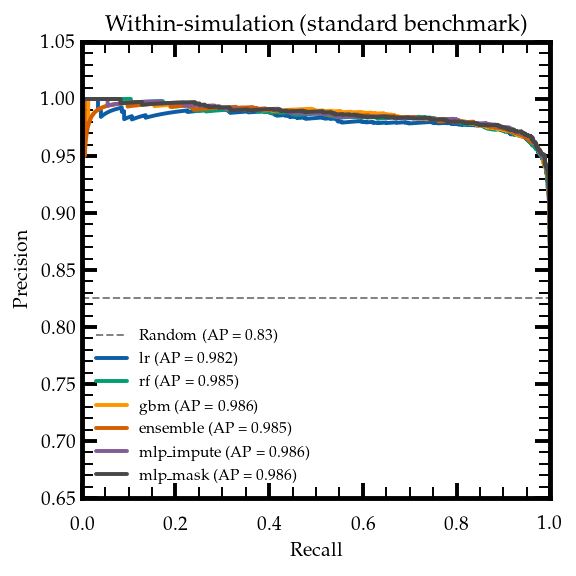

In [54]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
_ = plot_pr_curve(y_test_within_sim, probas_within_sim, ax=ax)
_ = ax.set_ylim(0.65, 1.05)
_ = ax.set_title("Within-simulation (standard benchmark)")

### ROC curves

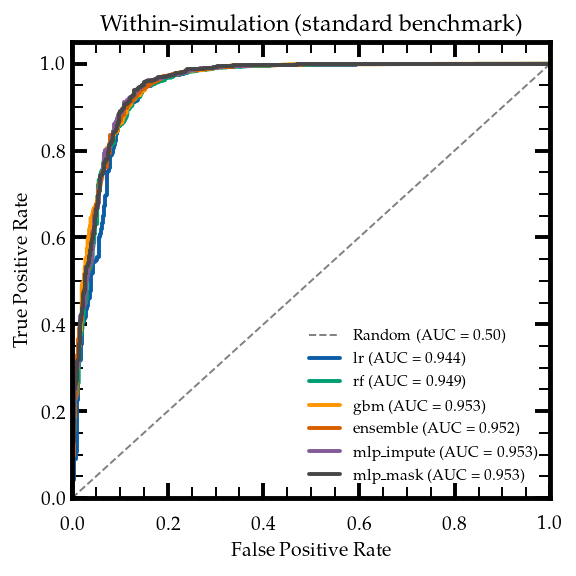

In [29]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
_ = plot_roc_curve(y_test_within_sim, probas_within_sim, ax=ax)
_ = ax.set_title("Within-simulation (standard benchmark)")

### Confusion matrices

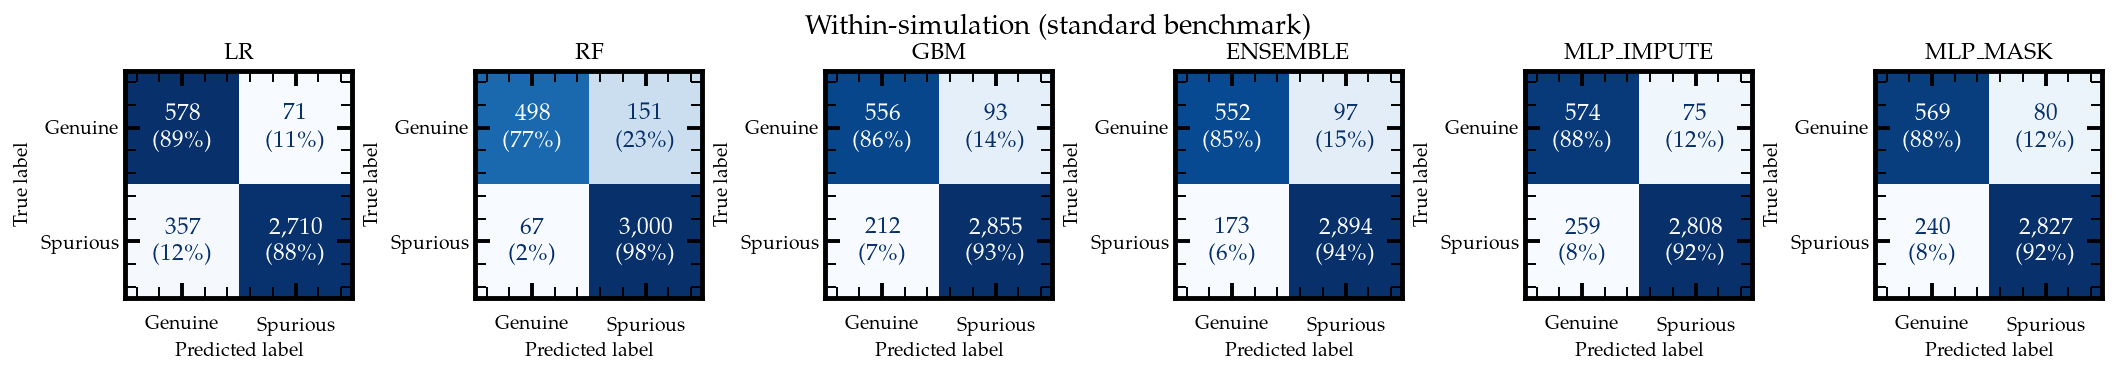

In [57]:
n_models = len(pipelines_within_sim) + sum(
    1 for n in MLP_NAMES if n in probas_within_sim
)
fig, axes = plt.subplots(1, len(preds_within_sim), figsize=(2.5 * len(preds_within_sim), 2.5), constrained_layout=True)
if len(preds_within_sim) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds_within_sim.items()):
    _ = plot_confusion_matrix(y_test_within_sim, y_pred, model_name=name.upper(), ax=ax)

_ = fig.suptitle("Within-simulation (standard benchmark)", y=1.02)

## Cross-softening (fixed -> tidal adaptive)

Train on `wdm_512_z39_fixed`, and test on `wdm_512_z39_adapt`. 

Tidal adaptive softening shifts halo formation times in WDM, introducing a real physical difference between train and test.

### Metrics summary

In [31]:
get_mlflow_metrics("cross_softening")

model,test_average_precision,test_roc_auc,test_f1,test_f1_genuine,test_precision,test_recall,test_precision_genuine,test_recall_genuine
str,f64,f64,f64,f64,f64,f64,f64,f64
"""ensemble""",0.977717,0.932293,0.95165,0.780231,0.944517,0.958891,0.807965,0.754338
"""rf""",0.976488,0.931703,0.951114,0.779445,0.945241,0.95706,0.801923,0.758193
"""lr""",0.973276,0.92008,0.913548,0.699966,0.959483,0.871811,0.600236,0.839438
"""gbm""",0.972847,0.924001,0.955966,0.774812,0.930424,0.98295,0.901352,0.679427
"""mlp_mask""",0.971579,0.918518,0.9425,0.761376,0.951538,0.933632,0.732502,0.792619
"""mlp_impute""",0.969415,0.919526,0.935687,0.744768,0.953283,0.918729,0.693936,0.803635


### Load test data and models

In [32]:
X_test_cross_softening, y_test_cross_softening = load_test_data("cross_softening")
col_means_cross_softening = compute_train_means("cross_softening")

# Sklearn models.
pipelines_cross_softening = {
    name: load_model(MODELS_DIR / f"{name}_cross_softening.joblib")
    for name in SKL_MODELS
    if (MODELS_DIR / f"{name}_cross_softening.joblib").exists()
}

probas_cross_softening = {
    name: pipeline.predict_proba(X_test_cross_softening)[:, 1]
    for name, pipeline in pipelines_cross_softening.items()
}

preds_cross_softening = {
    name: (proba >= 0.5).astype(int)
    for name, proba in probas_cross_softening.items()
}

# MLP models.
for mlp_name in MLP_NAMES:
    path = MODELS_DIR / f"{mlp_name}_cross_softening.pt"
    if path.exists():
        mlp = load_mlp_model(mlp_name, path)
        use_mask = mlp_name == "mlp_mask"
        probas_cross_softening[mlp_name] = get_mlp_proba(mlp, X_test_cross_softening, use_mask, col_means_cross_softening)
        preds_cross_softening[mlp_name] = (probas_cross_softening[mlp_name] >= 0.5).astype(int)

print(f"Models loaded: {list(probas_cross_softening.keys())}")

Models loaded: ['lr', 'rf', 'gbm', 'ensemble', 'mlp_impute', 'mlp_mask']


### Precision-recall curves

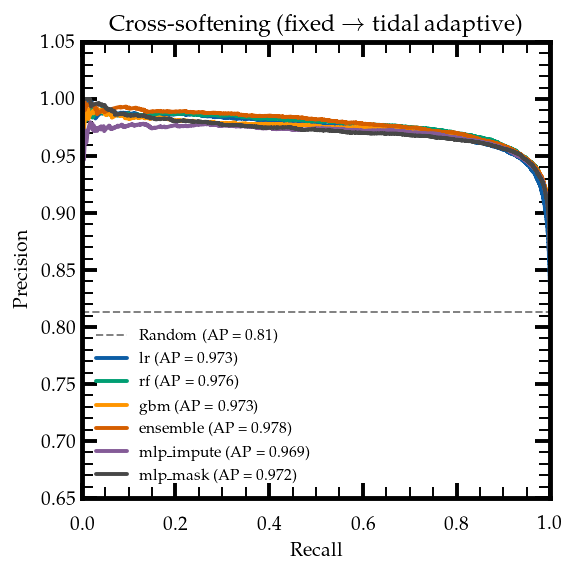

In [64]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
_ = plot_pr_curve(y_test_cross_softening, probas_cross_softening, ax=ax)
_ = ax.set_ylim(0.65, 1.05)
_ = ax.set_title(r"Cross-softening (fixed $\rightarrow$ tidal adaptive)")

### ROC curves

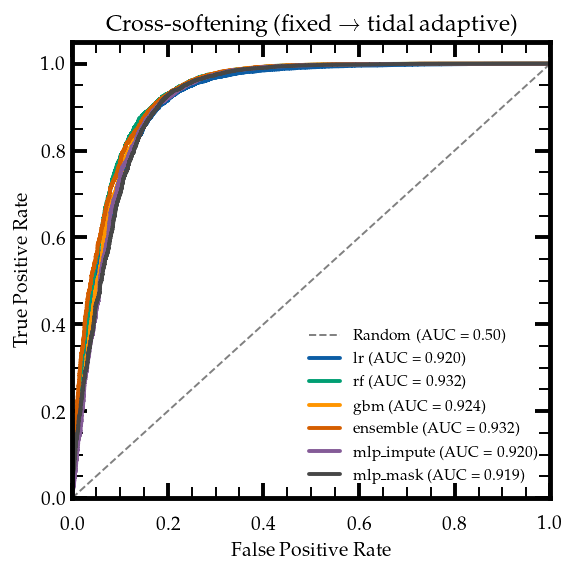

In [34]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
_ = plot_roc_curve(y_test_cross_softening, probas_cross_softening, ax=ax)
_ = ax.set_title("Cross-softening (fixed → tidal adaptive)")

### Confusion matrices

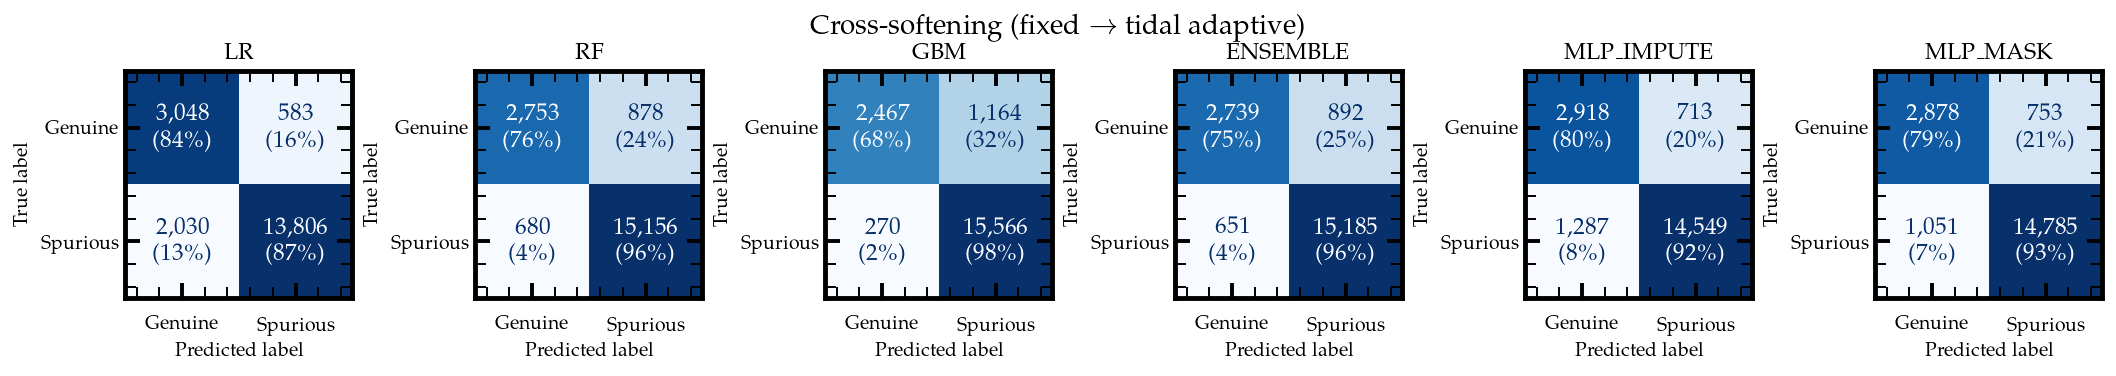

In [65]:
n_models = len(pipelines_cross_softening) + sum(
    1 for n in MLP_NAMES if n in probas_cross_softening
)

fig, axes = plt.subplots(1, len(preds_cross_softening), figsize=(2.5 * len(preds_cross_softening), 2.5), constrained_layout=True)
if len(preds_cross_softening) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds_cross_softening.items()):
    _ = plot_confusion_matrix(y_test_cross_softening, y_pred, model_name=name.upper(), ax=ax)

_ = fig.suptitle(r"Cross-softening (fixed $\rightarrow$ tidal adaptive)", y=1.02)

## Cross-z_ini (z=39 -> z=99, most challenging)

Train on `wdm_512_z39_fixed`, and test on `wdm_512_z99_fixed`. 

Earlier initialisation produces ~6\% lower protohalo sphericities (Fig. 7, Mostoghiu Paun et al. 2025). This split tests whether the CDM-match label is more robust to that shift than the empirical sphericity label.

### Metrics summary

In [36]:
get_mlflow_metrics("cross_z_ini")

model,test_average_precision,test_roc_auc,test_f1,test_f1_genuine,test_precision,test_recall,test_precision_genuine,test_recall_genuine
str,f64,f64,f64,f64,f64,f64,f64,f64
"""rf""",0.982771,0.946115,0.958752,0.806486,0.958973,0.958531,0.805616,0.807359
"""gbm""",0.98167,0.943413,0.964586,0.814363,0.947322,0.982491,0.900375,0.743352
"""ensemble""",0.981045,0.941394,0.958947,0.806572,0.958443,0.959452,0.808577,0.804576
"""mlp_impute""",0.980484,0.940178,0.935654,0.745325,0.967386,0.905937,0.659681,0.856524
"""mlp_mask""",0.980233,0.939283,0.94715,0.774378,0.964135,0.930753,0.720213,0.837353
"""lr""",0.977266,0.93033,0.929826,0.729095,0.966615,0.895735,0.635695,0.854669


### Load test data and models

In [37]:
X_test_cross_z_ini, y_test_cross_z_ini = load_test_data("cross_z_ini")
col_means_cross_z_ini = compute_train_means("cross_z_ini")

# Sklearn models.
pipelines_cross_z_ini = {
    name: load_model(MODELS_DIR / f"{name}_cross_z_ini.joblib")
    for name in SKL_MODELS
    if (MODELS_DIR / f"{name}_cross_z_ini.joblib").exists()
}

probas_cross_z_ini = {
    name: pipeline.predict_proba(X_test_cross_z_ini)[:, 1]
    for name, pipeline in pipelines_cross_z_ini.items()
}

preds_cross_z_ini = {
    name: (proba >= 0.5).astype(int)
    for name, proba in probas_cross_z_ini.items()
}

# MLP models.
for mlp_name in MLP_NAMES:
    path = MODELS_DIR / f"{mlp_name}_cross_z_ini.pt"
    if path.exists():
        mlp = load_mlp_model(mlp_name, path)
        use_mask = mlp_name == "mlp_mask"
        probas_cross_z_ini[mlp_name] = get_mlp_proba(mlp, X_test_cross_z_ini, use_mask, col_means_cross_z_ini)
        preds_cross_z_ini[mlp_name] = (probas_cross_z_ini[mlp_name] >= 0.5).astype(int)

print(f"Models loaded: {list(probas_cross_z_ini.keys())}")

Models loaded: ['lr', 'rf', 'gbm', 'ensemble', 'mlp_impute', 'mlp_mask']


### Precision-recall curves

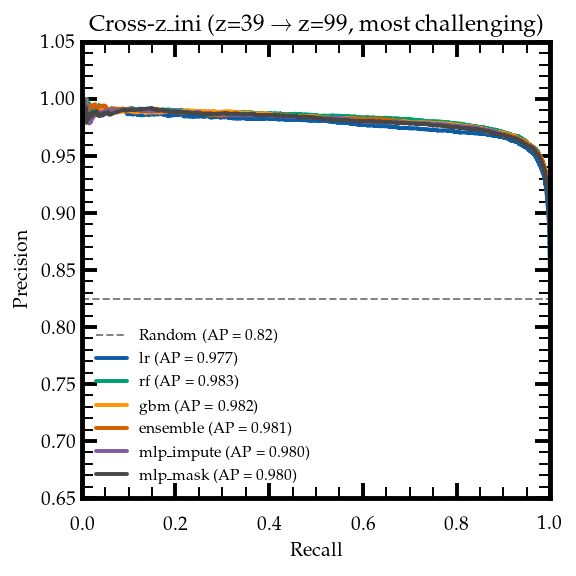

In [66]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
_ = plot_pr_curve(y_test_cross_z_ini, probas_cross_z_ini, ax=ax)
_ = ax.set_ylim(0.65, 1.05)
_ = ax.set_title("Cross-z_ini (z=39 → z=99, most challenging)")

### ROC curves

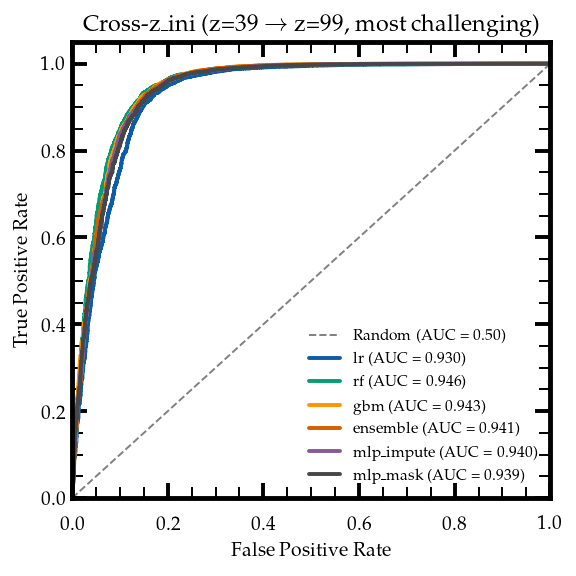

In [67]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
_ = plot_roc_curve(y_test_cross_z_ini, probas_cross_z_ini, ax=ax)
_ = ax.set_title(r"Cross-z_ini (z=39 $\rightarrow$ z=99, most challenging)")

### Confusion matrices

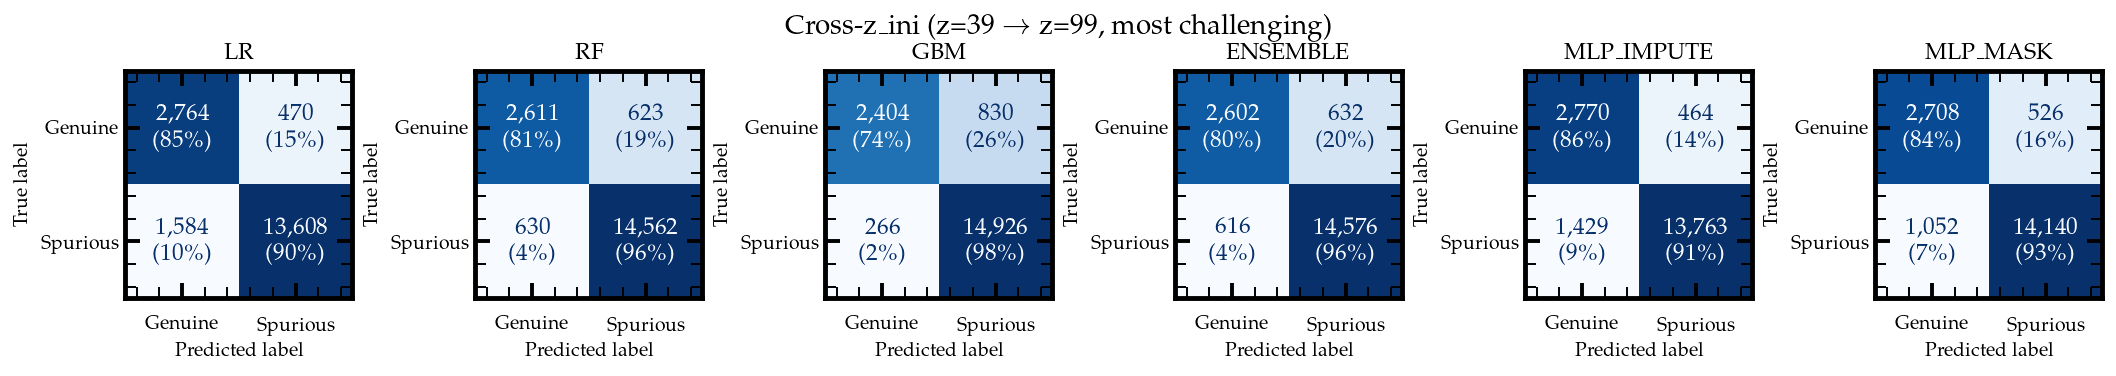

In [68]:
n_models = len(pipelines_cross_z_ini) + sum(
    1 for n in MLP_NAMES if n in probas_cross_z_ini
)

fig, axes = plt.subplots(1, len(preds_cross_z_ini), figsize=(2.5 * len(preds_cross_z_ini), 2.5), constrained_layout=True)
if len(preds_cross_z_ini) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds_cross_z_ini.items()):
    _ = plot_confusion_matrix(y_test_cross_z_ini, y_pred, model_name=name.upper(), ax=ax)

_ = fig.suptitle(r"Cross-z_ini (z=39 $\rightarrow$ z=99, most challenging)", y=1.02)

## Cross-split generalisation summary

Here we compares how each model degrades as the test distribution shifts away from the training distribution. 

The drop from `within_sim` to `cross_z_ini` is the headline scientific result.


In [41]:
all_runs = mlflow.search_runs(experiment_names=["spurious_halo_classifier"])

if not all_runs.empty:
    summary = (
        pl.from_pandas(
            all_runs[[
                "params.model",
                "params.split_name",
                "metrics.test_average_precision",
                "metrics.test_roc_auc",
                "metrics.test_f1",
                "metrics.test_f1_genuine",
            ]]
        )
        .rename({
            "params.model":                   "model",
            "params.split_name":              "split",
            "metrics.test_average_precision": "avg_precision",
            "metrics.test_roc_auc":           "roc_auc",
            "metrics.test_f1":                "f1",
            "metrics.test_f1_genuine":        "f1_genuine",
        })
        .sort(["split", "avg_precision"], descending=[False, True])
    )
    print(summary)


shape: (18, 6)
┌────────────┬─────────────────┬───────────────┬──────────┬──────────┬────────────┐
│ model      ┆ split           ┆ avg_precision ┆ roc_auc  ┆ f1       ┆ f1_genuine │
│ ---        ┆ ---             ┆ ---           ┆ ---      ┆ ---      ┆ ---        │
│ str        ┆ str             ┆ f64           ┆ f64      ┆ f64      ┆ f64        │
╞════════════╪═════════════════╪═══════════════╪══════════╪══════════╪════════════╡
│ ensemble   ┆ cross_softening ┆ 0.977717      ┆ 0.932293 ┆ 0.95165  ┆ 0.780231   │
│ rf         ┆ cross_softening ┆ 0.976488      ┆ 0.931703 ┆ 0.951114 ┆ 0.779445   │
│ lr         ┆ cross_softening ┆ 0.973276      ┆ 0.92008  ┆ 0.913548 ┆ 0.699966   │
│ gbm        ┆ cross_softening ┆ 0.972847      ┆ 0.924001 ┆ 0.955966 ┆ 0.774812   │
│ mlp_mask   ┆ cross_softening ┆ 0.971579      ┆ 0.918518 ┆ 0.9425   ┆ 0.761376   │
│ …          ┆ …               ┆ …             ┆ …        ┆ …        ┆ …          │
│ mlp_impute ┆ within_sim      ┆ 0.986194      ┆ 0.952973 ┆ 0

In [42]:
# Avg precision drop: within_sim -> cross_z_ini per model.
if not all_runs.empty:
    within = (
        summary
        .filter(pl.col("split") == "within_sim")
        .select(["model", "avg_precision"])
        .rename({"avg_precision": "within_sim"})
    )
    cross = (
        summary
        .filter(pl.col("split") == "cross_z_ini")
        .select(["model", "avg_precision"])
        .rename({"avg_precision": "cross_z_ini"})
    )
    drop = (
        within.join(cross, on="model")
        .with_columns(
            (pl.col("within_sim") - pl.col("cross_z_ini")).alias("drop")
        )
        .sort("drop", descending=True)
    )
    print(drop)


shape: (6, 4)
┌────────────┬────────────┬─────────────┬──────────┐
│ model      ┆ within_sim ┆ cross_z_ini ┆ drop     │
│ ---        ┆ ---        ┆ ---         ┆ ---      │
│ str        ┆ f64        ┆ f64         ┆ f64      │
╞════════════╪════════════╪═════════════╪══════════╡
│ mlp_mask   ┆ 0.986471   ┆ 0.980233    ┆ 0.006238 │
│ mlp_impute ┆ 0.986194   ┆ 0.980484    ┆ 0.00571  │
│ lr         ┆ 0.981648   ┆ 0.977266    ┆ 0.004382 │
│ gbm        ┆ 0.985865   ┆ 0.98167     ┆ 0.004195 │
│ ensemble   ┆ 0.985178   ┆ 0.981045    ┆ 0.004133 │
│ rf         ┆ 0.985208   ┆ 0.982771    ┆ 0.002438 │
└────────────┴────────────┴─────────────┴──────────┘
